# IEEE 34 Node

In [20]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix

from unit_converter import UnitConverter
from topologia import FeederTopology

import fault
import fault1 
import fault2
# import fault3


import locator
import locator1
import locator2
import locator3

In [4]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('C:/Users/GREI-Luis-Felipe/Documents/GitHub/tcc-luis-felipe')

In [5]:
DSS_FILE_REG = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1.dss"
DSS_FILE_NO_REG = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_no_reg.dss"
DSS_FILE_MI_POS_REG = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_mi_pos_regulator.dss"
DSS_FILE_TAP_SET = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1_tap_setted.dss"



funcoes

In [16]:
def plot_erro(df6, simulador):
    mapa_faltas = {
        'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
        'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
        'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
        'abc': 'Falta Trifásica ABC'
    }

    # Lista de linhas do ramal principal
    ramal_principal = simulador.topology.get_main_branch()
    markers = ['o', 's', 'D', '^', 'v']

    # Configuração rigorosa do Matplotlib preservada
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['xtick.labelsize'] = 11
    plt.rcParams['ytick.labelsize'] = 11
    plt.rcParams['legend.fontsize'] = 10

    results_df = df6

    # --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
    col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
    resistencias_simuladas = sorted(results_df[col_resistencia].unique())

    # Calcula o limite máximo do eixo X
    limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

    # --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
    # Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
    # Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

    # Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
    axes = axes.flatten() 

    for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
        
        # Filtra apenas o tipo de falta atual e as linhas do ramal principal
        df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
        
        # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
        if df_tipo.empty:
            ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
            ax.axis('off') # Esconde as bordas do gráfico vazio
            continue

        # Iterar sobre as resistências simuladas para criar cada curva
        for i, res in enumerate(resistencias_simuladas):
            df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
            if df_plot.empty:
                continue

            # Converter metros para quilômetros
            df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
            
            # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
            df_plot = df_plot.sort_values(by='distancia_km')

            # Plotando direto no eixo atual (ax) em vez de plt
            marker_estilo = markers[i % len(markers)]
            ax.plot(df_plot['distancia_km'], 
                    df_plot['erro_percentual'], 
                    marker=marker_estilo, 
                    markersize=2, 
                    linestyle='-', 
                    linewidth=1.2, 
                    label=f'{res} $\\Omega$')

        # Configurações individuais do subplot atual
        ax.set_title(titulo_grafico, fontweight='bold')
        ax.set_xlim(0, limite_x_km)
        
        # Adicionamos rótulos nos eixos
        ax.set_xlabel("Distância do ponto de falta (km)")
        ax.set_ylabel("Erro (%)")
        
        ax.legend(title="Resistência", loc='upper right')
        ax.grid(True, linestyle="--", alpha=0.7)

    # Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
    plt.tight_layout()

    # Exibe o grid na tela
    plt.show()

## Medida SE, com regulador

In [6]:
simulador = fault.FaultSimulator(str(DSS_FILE_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df1 = localizador.df.copy()


Iniciando a varredura linear de curtos-circuitos...


Aplicando Filtro MI: 100%|██████████| 654/654 [00:00<00:00, 17674.57it/s]


In [7]:
df1.head(10)

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_5_line,circuito_6_d,circuito_6_line,circuito_7_d,circuito_7_line,circuito_8_d,circuito_8_line,linha_estimada,dist_estimada,erro_percentual
0,14894.615725,-140.507583,-7499.666998,-13044.186057,-7499.389192,13100.728891,37724.473700,-38336.462025,-20.001742,-29.313907,...,l1,235.915199,l1,235.915202,l1,235.915202,l1,l1,235.915194,-1.035774e-08
1,15094.512969,-55.551757,-7565.719247,-12829.479045,-7547.502015,13017.222161,36.810936,-2.147139,-52045.741869,-12771.856396,...,l1,235.915189,l1,235.915191,l1,235.915192,l1,l1,235.915185,-2.626484e-08
2,15046.726914,27.473241,-7595.583146,-13044.696868,-7326.841437,12967.935264,38.797908,-4.293853,-16.948896,-28.280336,...,l1,235.915191,l1,235.915192,l1,235.915193,l1,l1,235.915186,-2.389130e-08
3,14996.551276,-345.415013,-7449.427746,-12727.130476,-7547.158700,13072.549189,64080.789301,-6234.650738,-64063.881189,6180.095986,...,l1,235.915184,l1,235.915184,l1,235.915184,l1,l1,235.915185,-2.659390e-08
4,15094.713244,-0.297031,-7766.760488,-12812.157574,-7327.959899,12812.446276,56.547457,-10.283463,-38868.162516,-47055.028903,...,l1,235.915190,l1,235.915190,l1,235.915190,l1,l1,235.915190,-1.805754e-08
5,14753.955033,-71.346309,-7547.573149,-13072.303800,-7206.370805,13143.646388,23538.537560,-57827.070411,-29.158863,-34.003350,...,l1,235.915194,l1,235.915194,l1,235.915194,l1,l1,235.915193,-1.135882e-08
6,14933.760186,-310.757238,-7511.059721,-12690.889246,-7513.016024,13048.087585,56770.677788,-25250.157099,-71690.526385,-12681.858449,...,l1,235.915188,l1,235.915188,l1,235.915188,l1,l1,235.915189,-1.987770e-08
7,15054.533853,-19.686019,-7701.876456,-12772.686068,-7263.394574,12852.960316,34.533879,0.211392,-52648.179426,-30405.515596,...,l1,235.915186,l1,235.915186,l1,235.915186,l1,l1,235.915186,-2.404804e-08
8,14756.569525,-146.707491,-7544.144027,-13028.280211,-7205.120706,13068.539294,44634.579742,-54125.993636,-15.864376,-25.938595,...,l1,235.915194,l1,235.915194,l1,235.915194,l1,l1,235.915193,-1.176932e-08
9,14810.910962,-285.218196,-7622.970575,-12658.364681,-7182.206692,12947.008938,59160.299677,-40491.989305,-70884.509271,-26218.923584,...,l1,235.915185,l1,235.915185,l1,235.915185,l1,l1,235.915185,-2.613609e-08


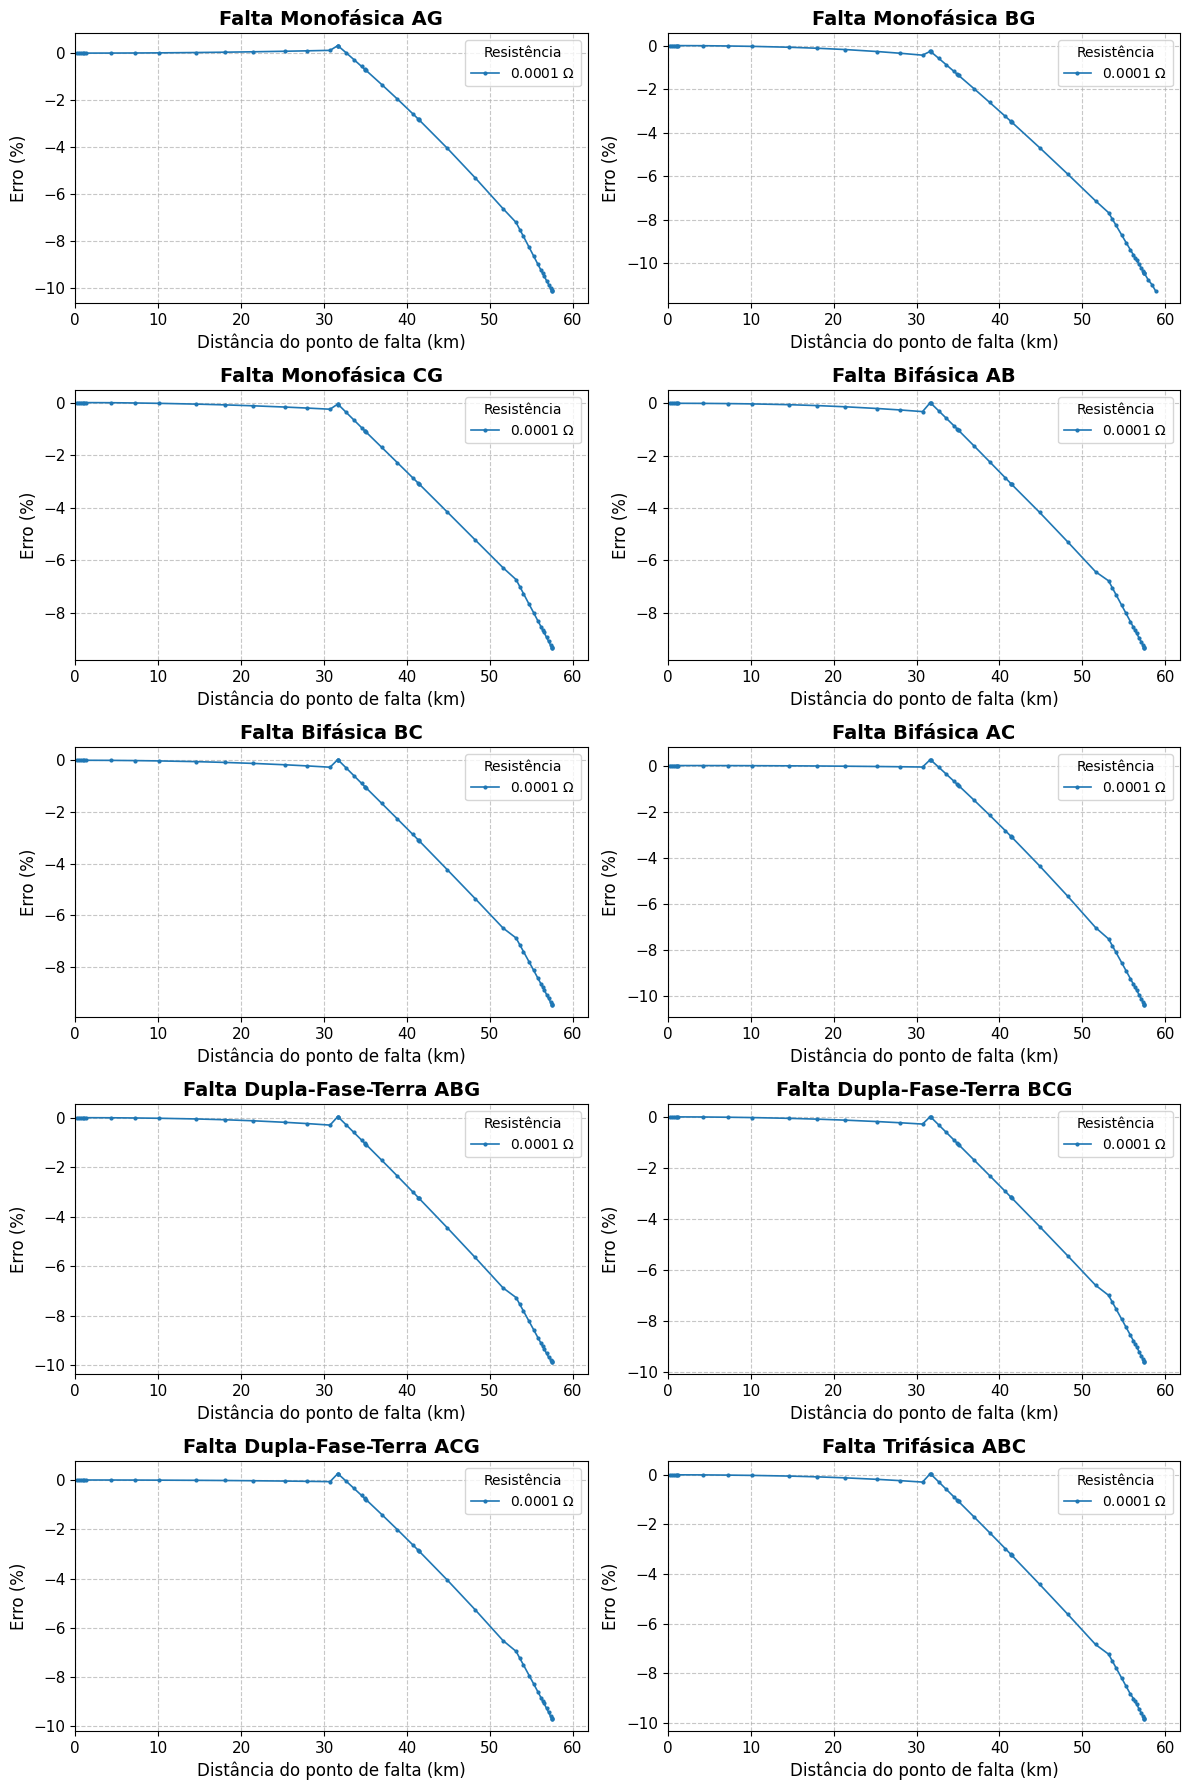

In [17]:
plot_erro(df1, simulador)

## Multiplas medidas, com regulador

In [21]:
simulador = fault1.FaultSimulator(str(DSS_FILE_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df2 = localizador.df.copy()



Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 654/654 [01:02<00:00, 10.39it/s]


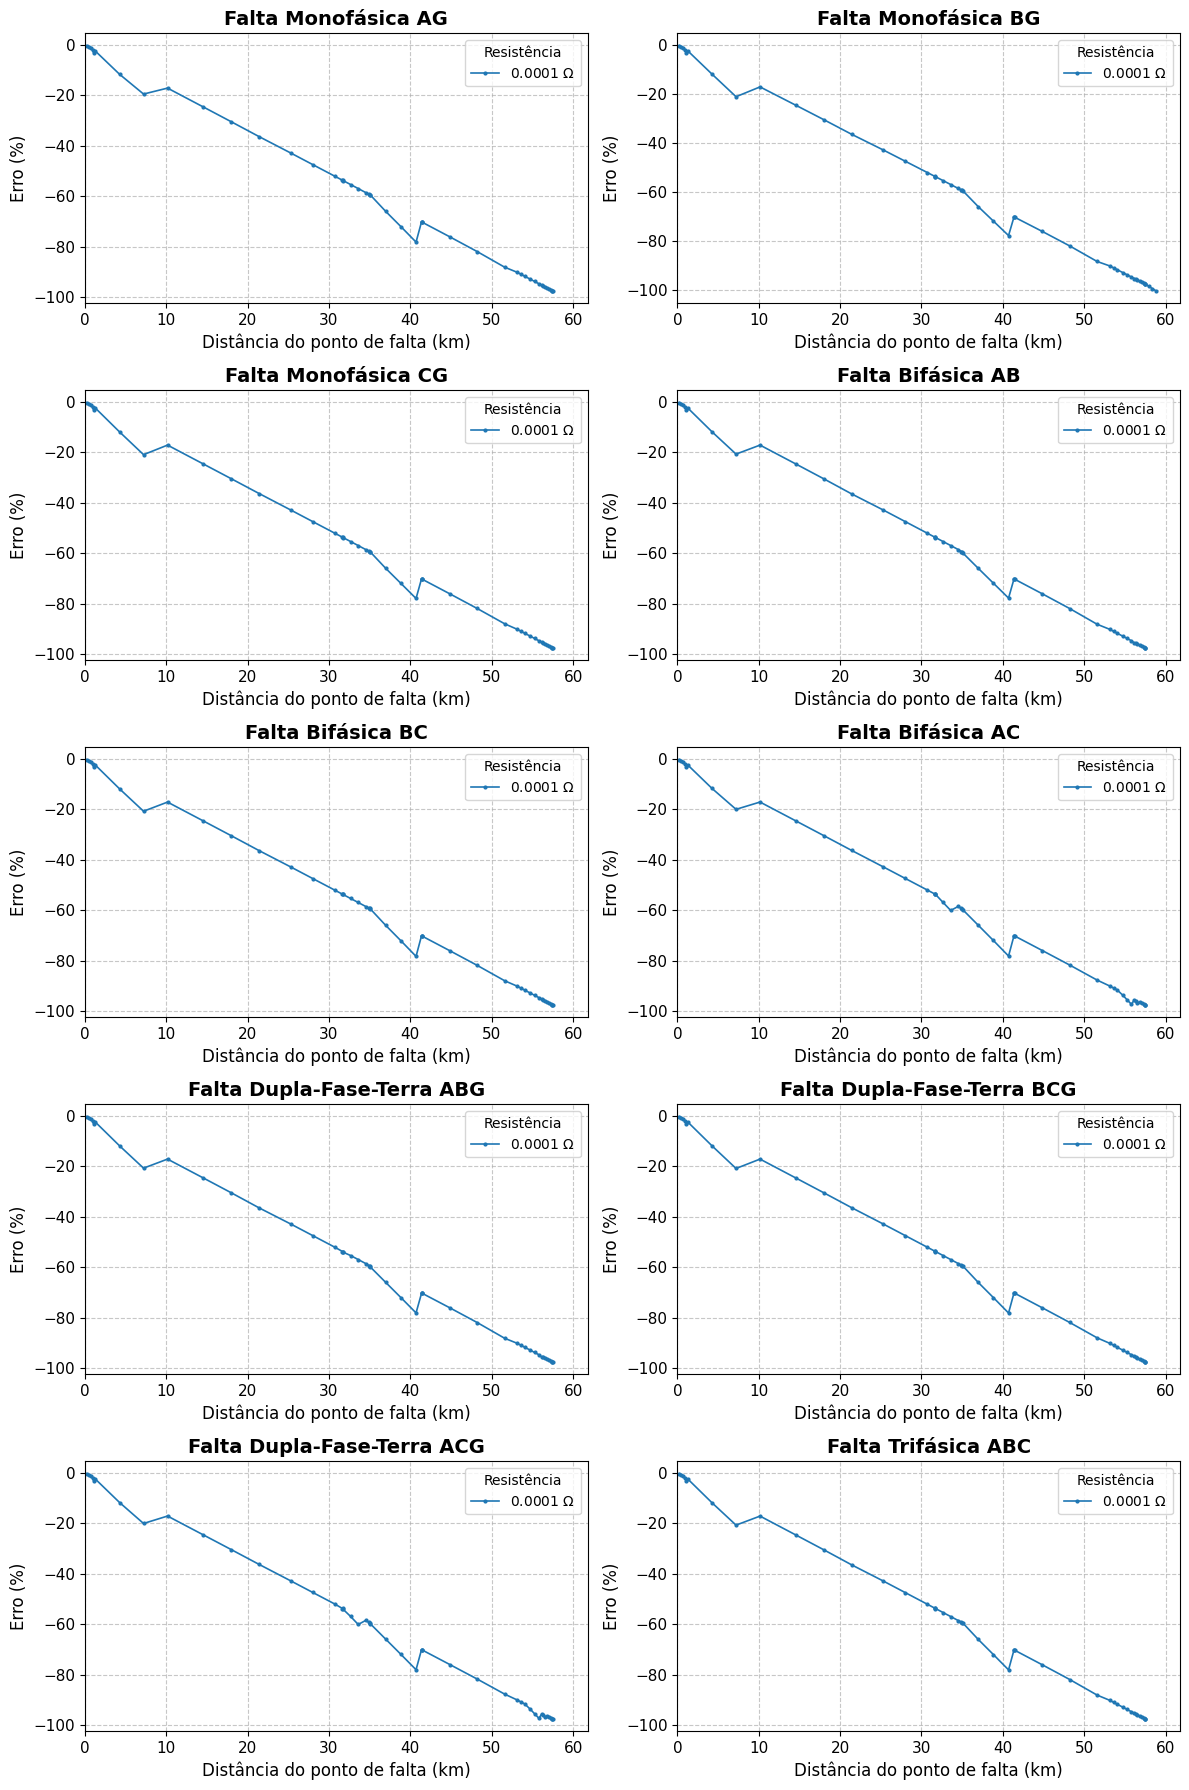

In [22]:
plot_erro(df2, simulador)

## Medida SE, sem regulador

In [11]:
simulador = fault.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df3 = localizador.df.copy()



Iniciando a varredura linear de curtos-circuitos...


Aplicando Filtro MI: 100%|██████████| 654/654 [00:00<00:00, 17481.95it/s]


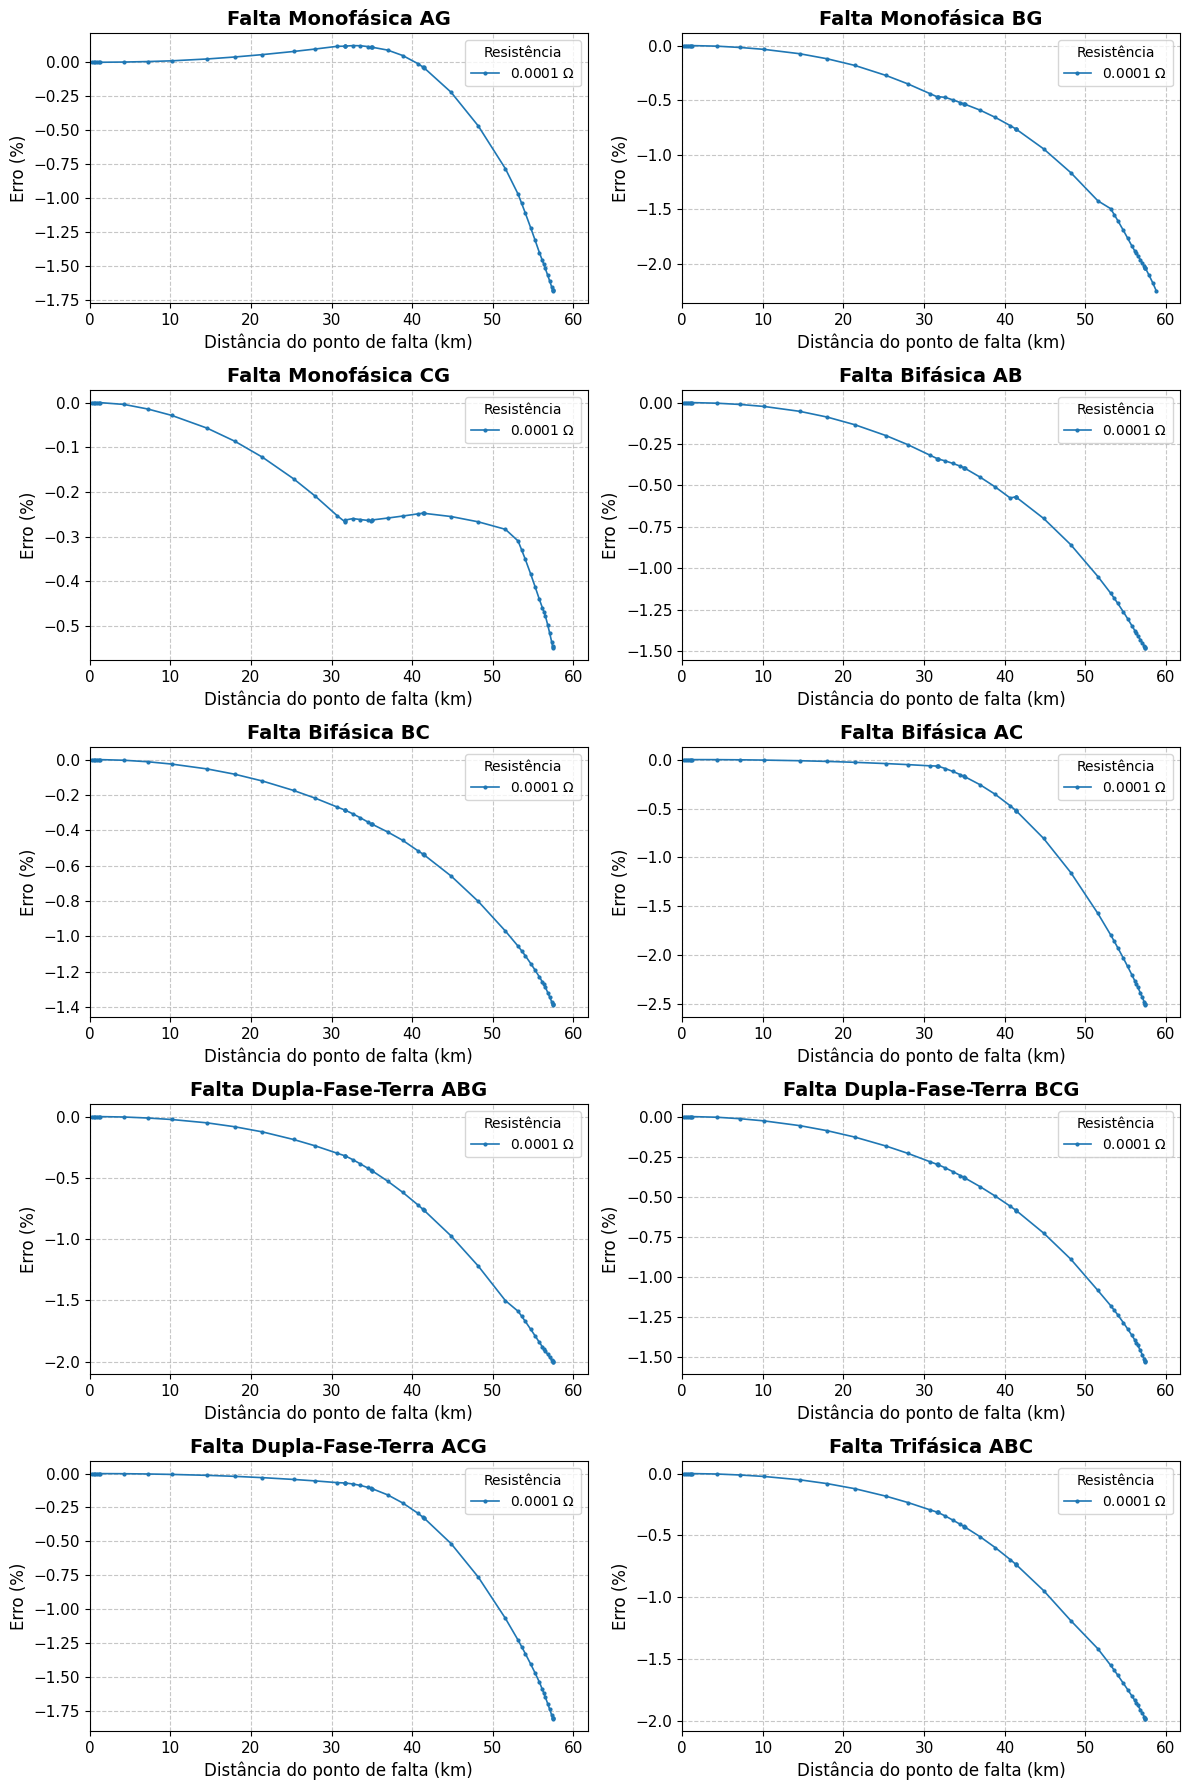

In [12]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = localizador.df.copy()

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()

## Multiplas medidas, sem regulador

In [13]:
simulador = FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df4 = localizador.df.copy()



Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 654/654 [00:57<00:00, 11.34it/s]


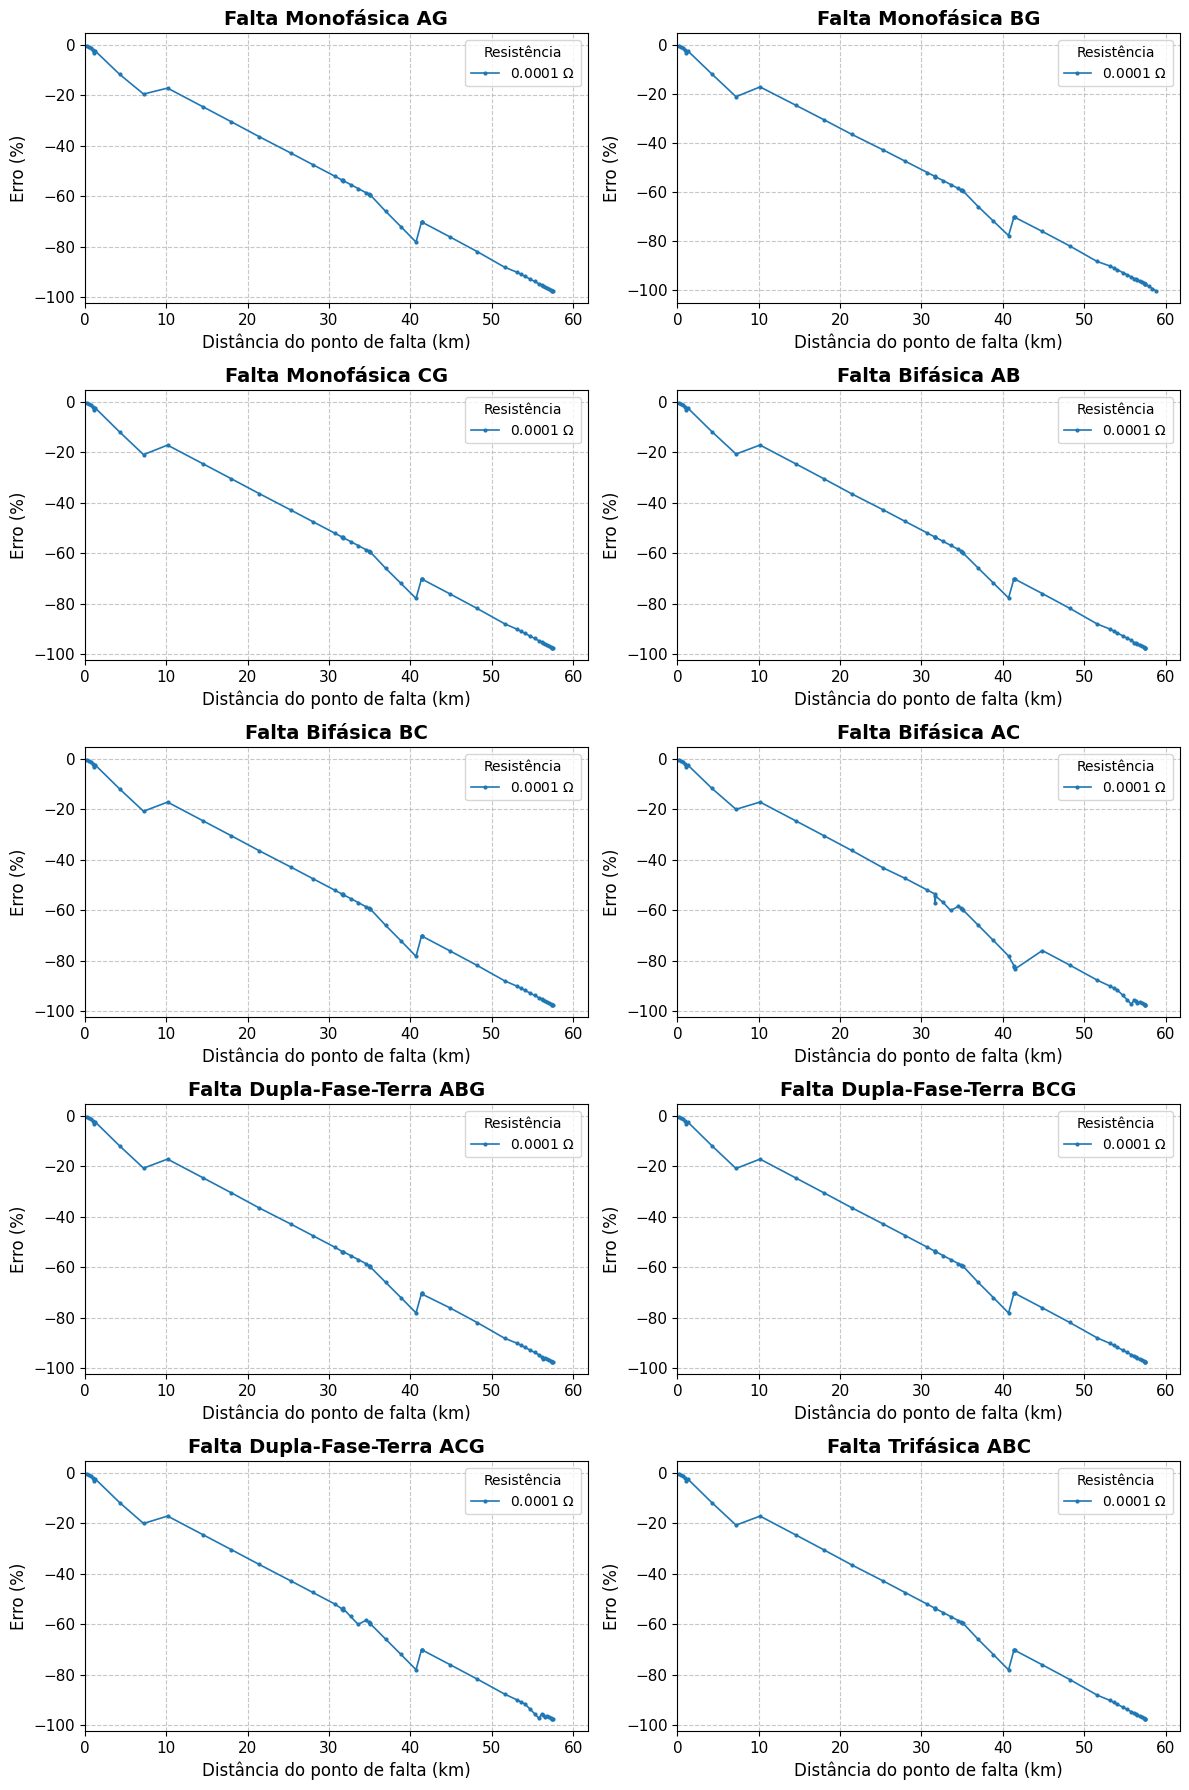

In [14]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = localizador.df.copy()

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()

## Multiplas medidas, com regulador, medida após regulador

In [15]:
simulador = FaultSimulator(str(DSS_FILE_MI_POS_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = FaultLocator(str(DSS_FILE_MI_POS_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df5 = localizador.df.copy()



Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 654/654 [01:04<00:00, 10.09it/s]


## Multiplas medidas, com regulador, versão 3

Nesta versão a impedância do transformador é incrementada

In [7]:
simulador = fault2.FaultSimulator(str(DSS_FILE_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator2.FaultLocator(str(DSS_FILE_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df6 = localizador.df.copy()



Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 654/654 [02:19<00:00,  4.68it/s]


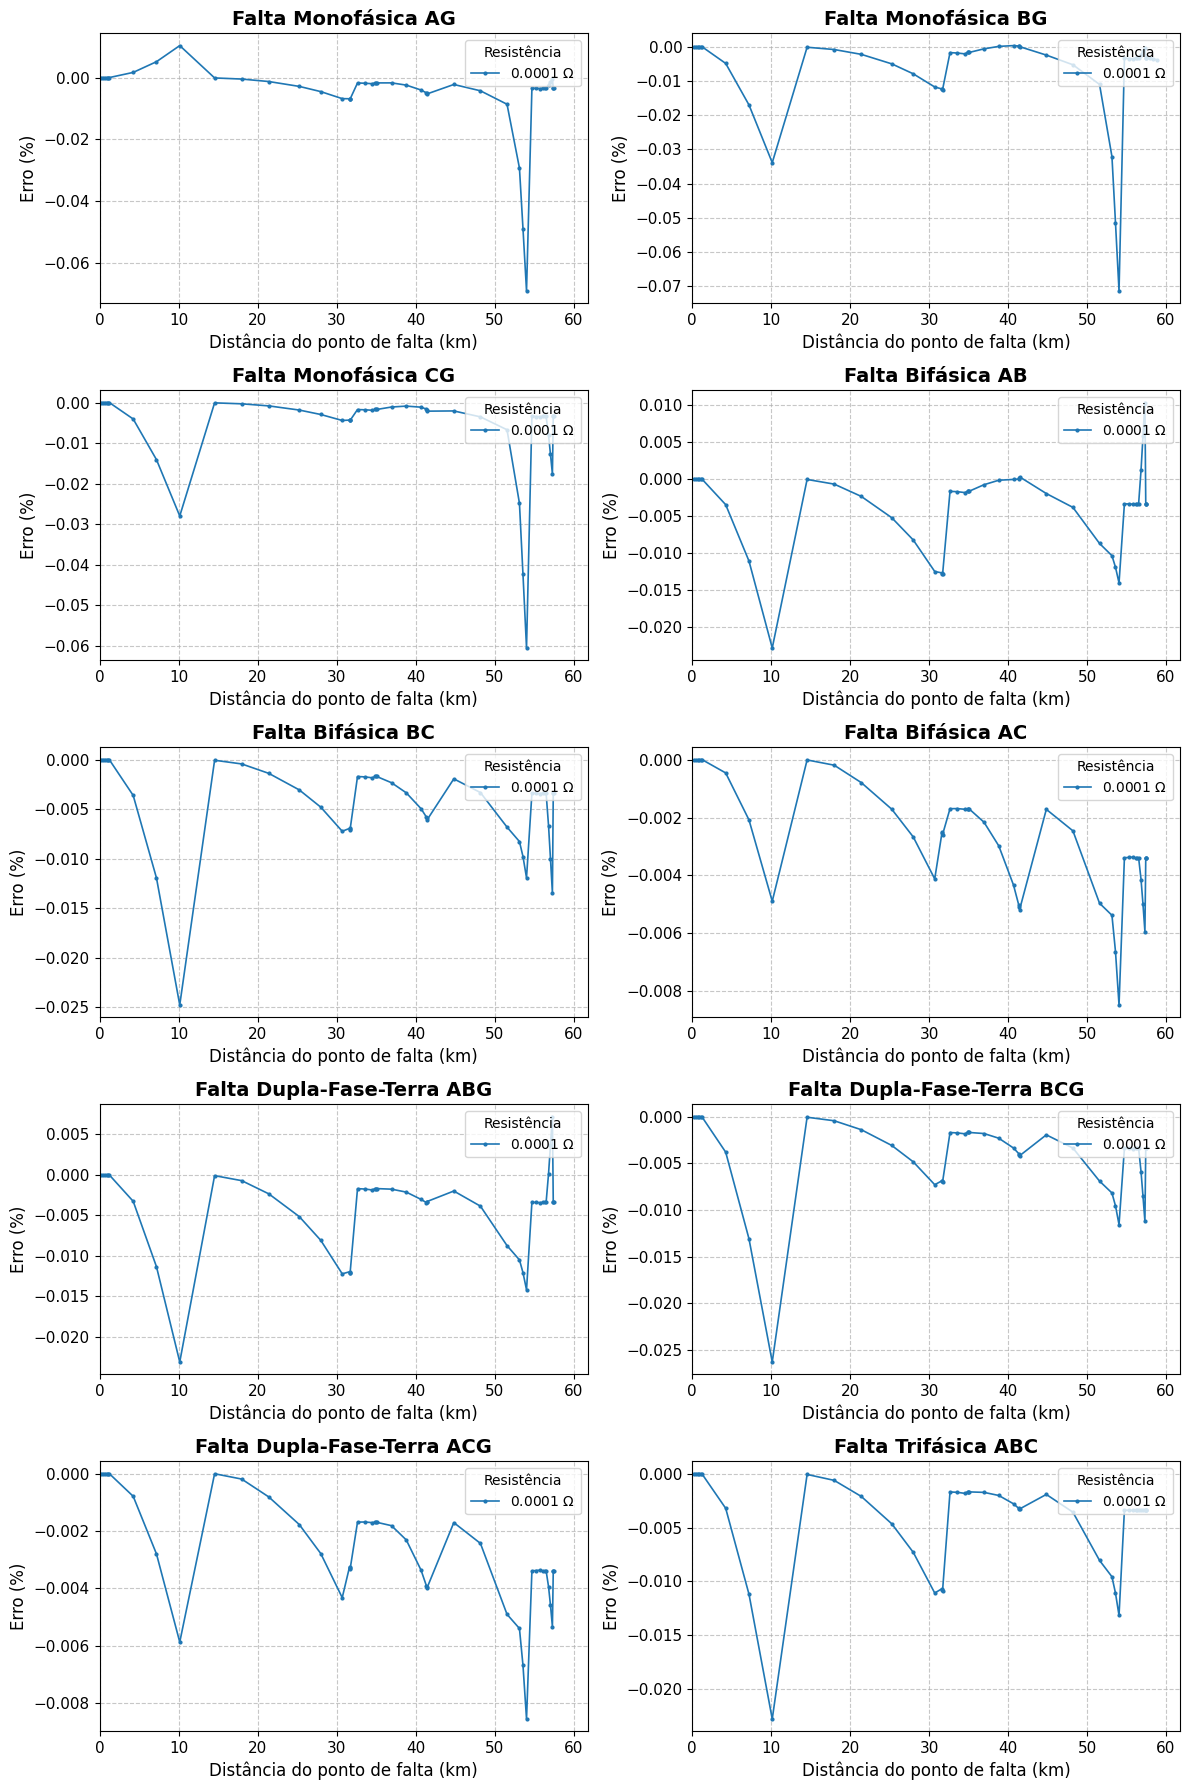

In [8]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = df6

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()

## Multiplas medidas, com regulador, versão 4

Nesta versão a impedância do transformador não é incrementada

In [4]:
simulador = fault2.FaultSimulator(str(DSS_FILE_REG), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator3.FaultLocator(str(DSS_FILE_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df7 = localizador.df.copy()



Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 654/654 [02:38<00:00,  4.12it/s]


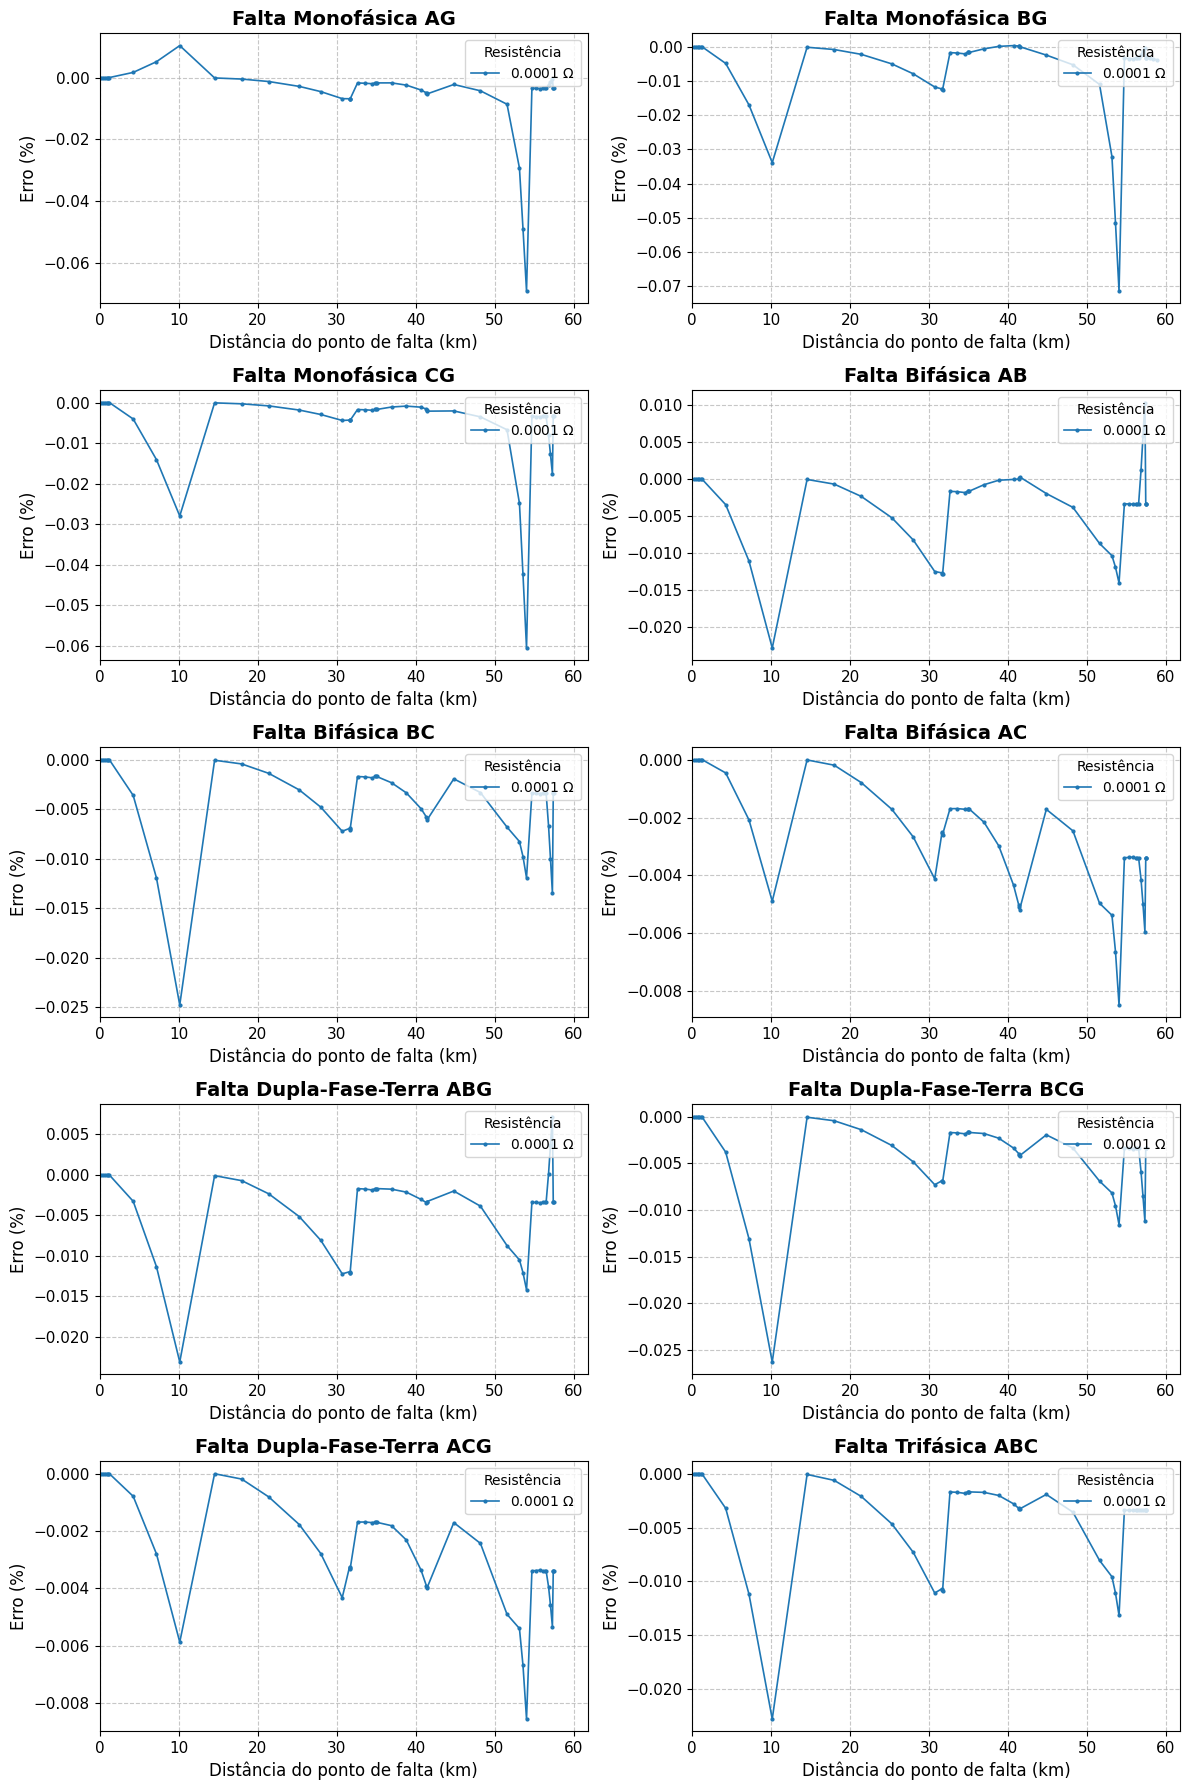

In [5]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = df7

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()

## Multiplas medidas, com regulador, versão 5

Nesta versão a impedância do transformador é incrementada

In [5]:
simulador = fault2.FaultSimulator(str(DSS_FILE_TAP_SET), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator3.FaultLocator(str(DSS_FILE_TAP_SET), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df8 = localizador.df.copy()



Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 654/654 [02:49<00:00,  3.86it/s]


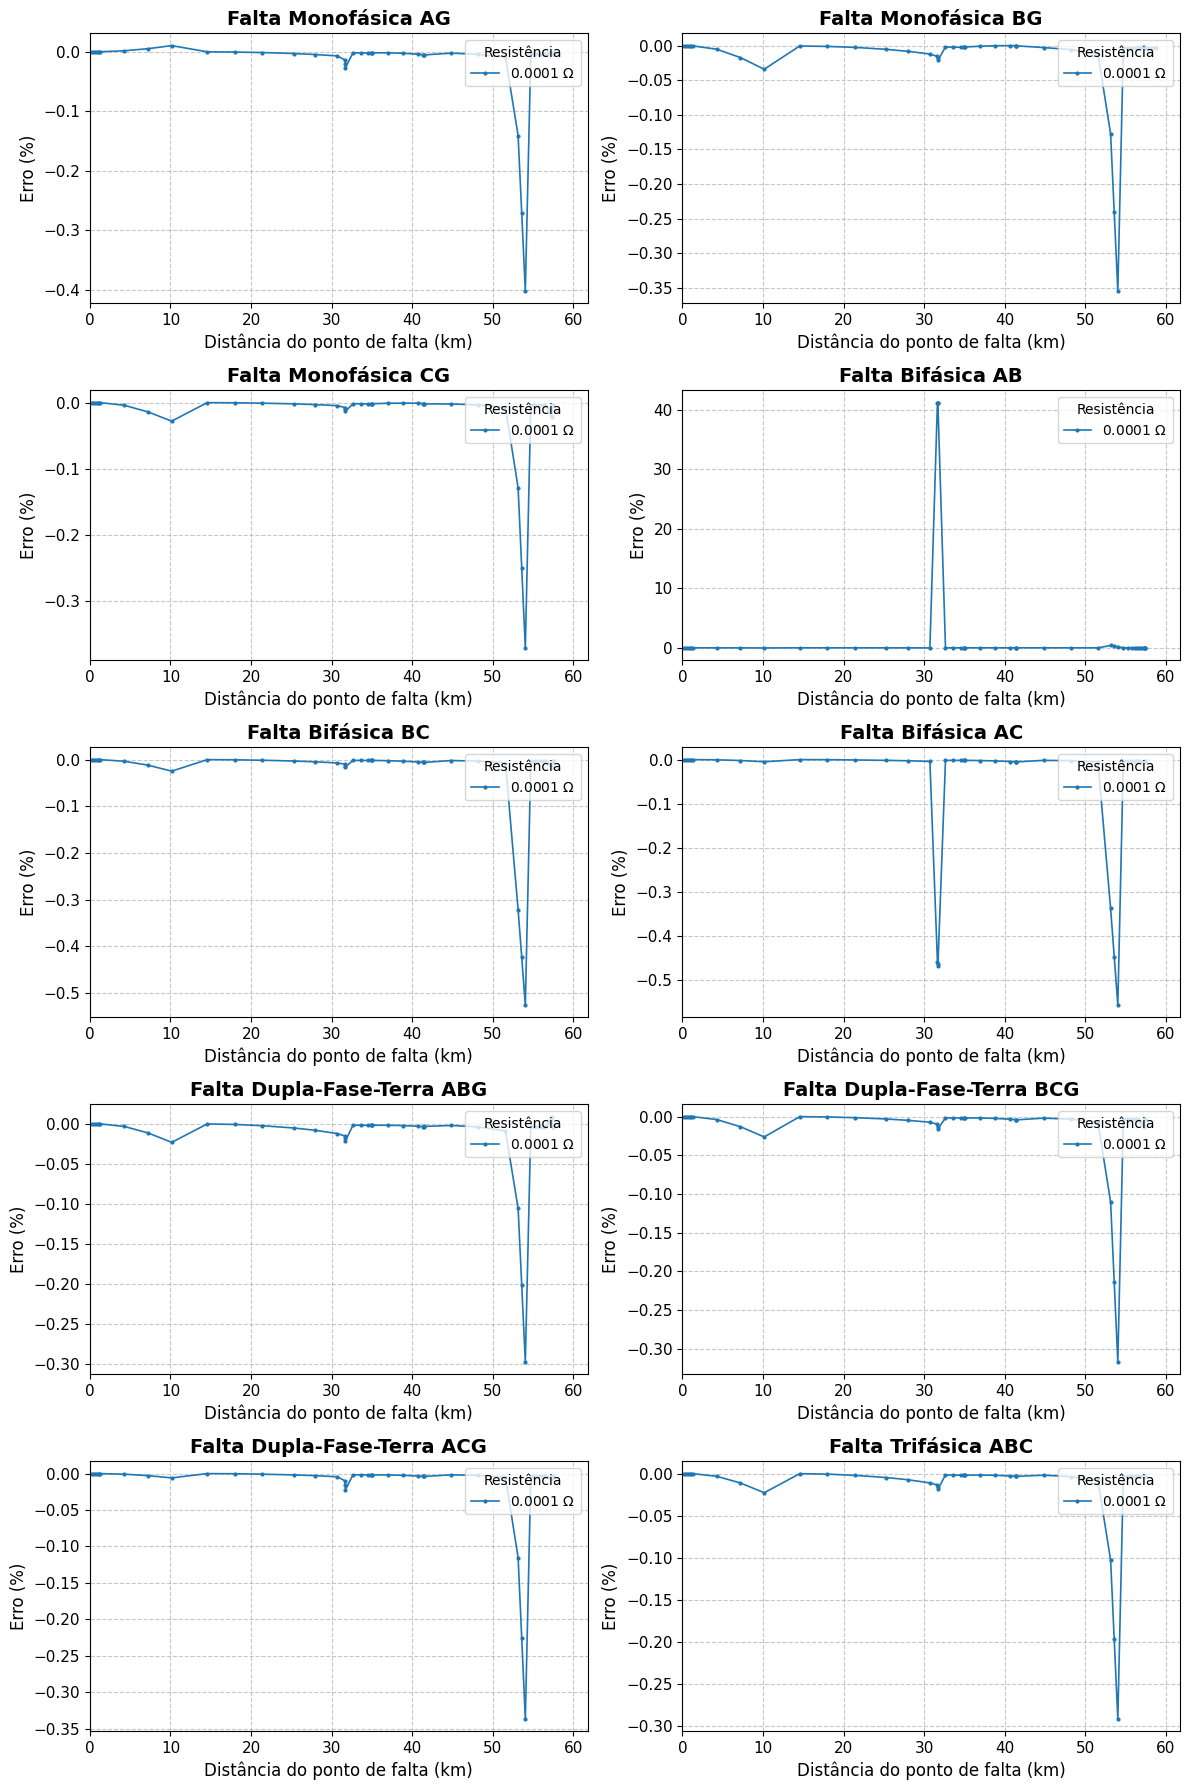

In [6]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = df8

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()

## Comparação

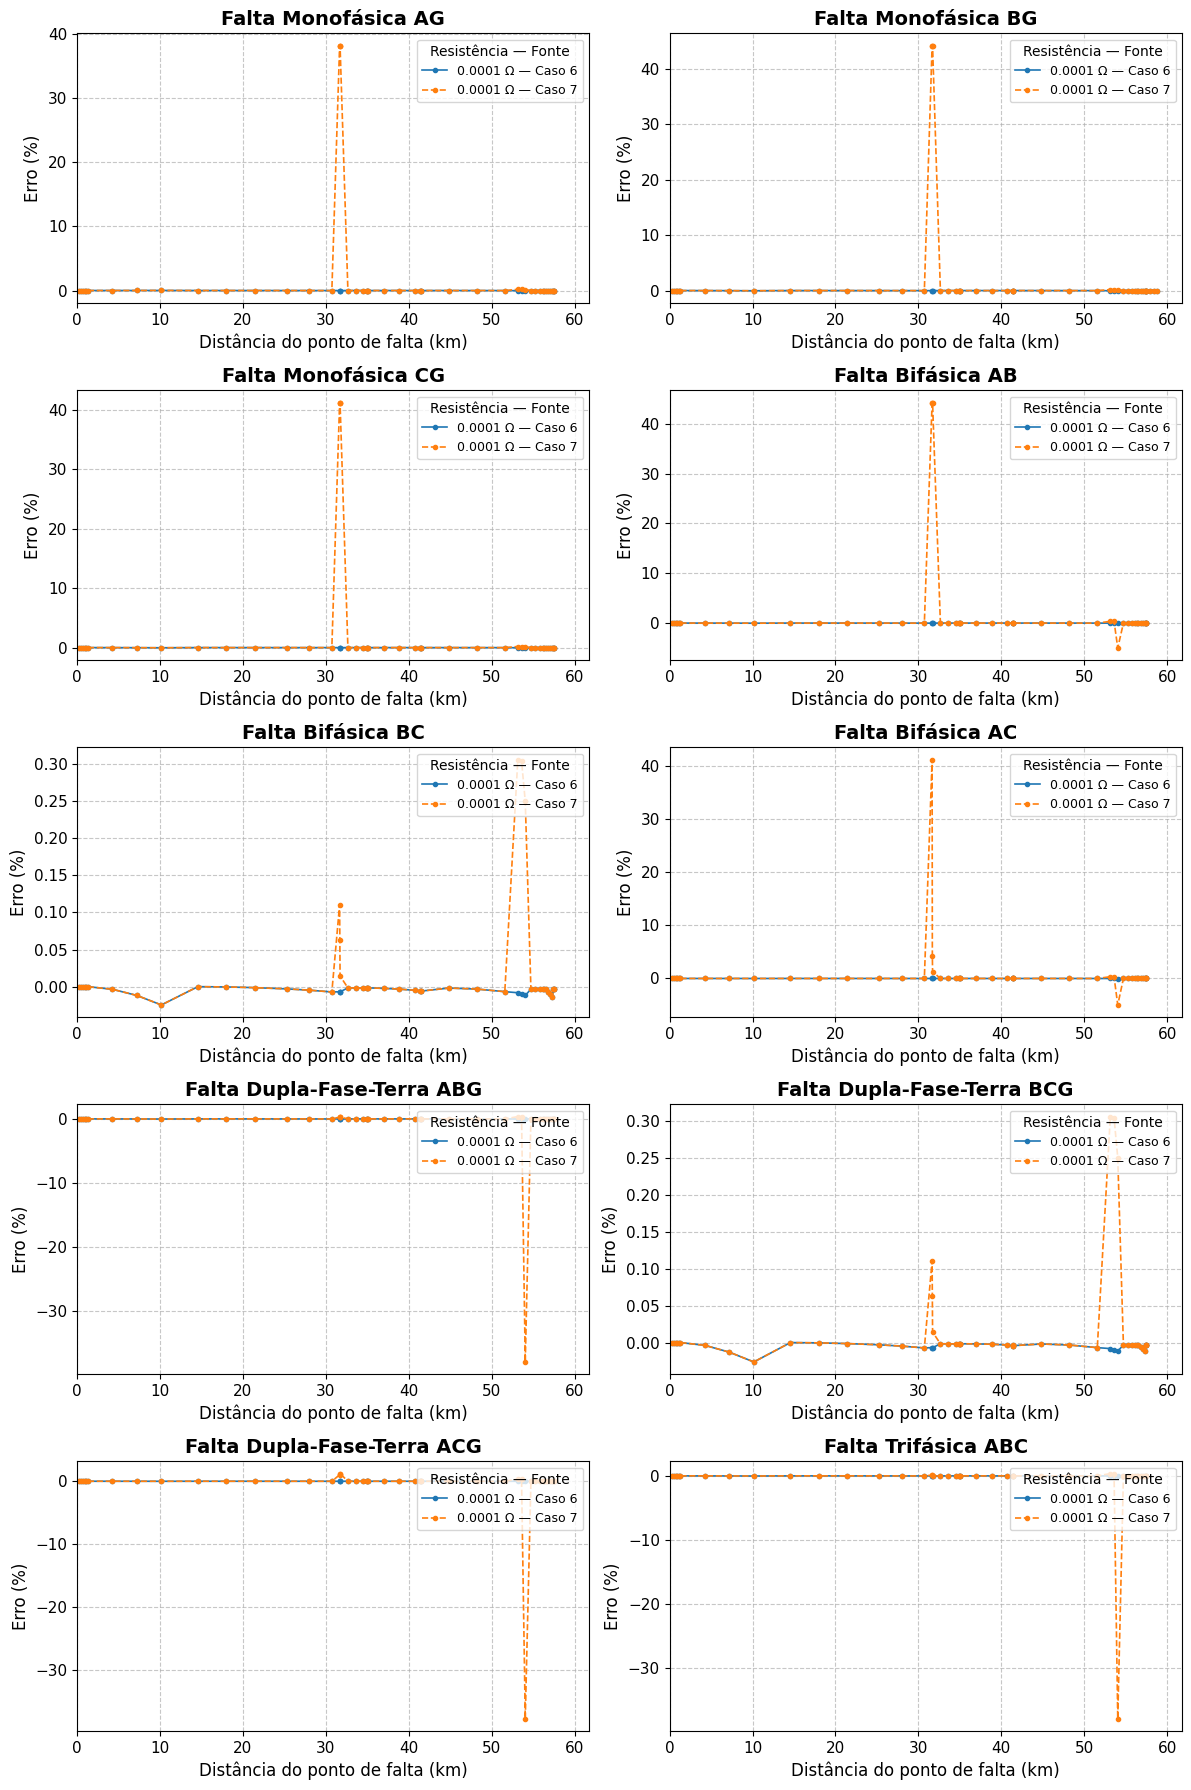

In [ ]:
# Lista de dataframes e nomes para legenda
dfs = [
    # (df1, 'Caso 1'),
    # (df2, 'Caso 2'),
    # (df3, 'Caso 3'),
    # (df4, 'Caso 4'),
    # (df5, 'Caso 5'),
    (df6, 'Caso 6'),
    (df7, 'Caso 7'),
]

# Marcadores, cores e estilos para diferenciar os dataframes
markers = ['o', 's', 'D', '^', 'v', 'P', 'X']
cores = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
linestyles = ['-', '--', '-.', ':']

# --- Configuração Matplotlib (preservada) ---
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 9

# --- 1. Determinar coluna de resistência e resistências simuladas combinadas ---
def get_res_col(df):
    if df is None or df.empty:
        return None
    return 'r_f' if 'r_f' in df.columns else ('r' if 'r' in df.columns else None)

# Coletar todas as resistências únicas entre os dataframes (mantendo ordem)
res_set = set()
for df, _ in dfs:
    col = get_res_col(df)
    if col:
        res_set.update(df[col].dropna().unique())
resistencias_simuladas = sorted(res_set)

# --- 2. Calcular limite X (km) usando todos os dataframes filtrando pelo ramal principal ---
# Concatena temporariamente as colunas 'linha_faltosa' e 'distancia' quando existirem
distancias = []
for df, _ in dfs:
    if df is None or df.empty:
        continue
    if 'linha_faltosa' in df.columns and 'distancia' in df.columns:
        mask = df['linha_faltosa'].isin(ramal_principal)
        if mask.any():
            maxd = df.loc[mask, 'distancia'].max()
            if pd.notna(maxd):
                distancias.append(maxd)

if distancias:
    limite_x_km = (max(distancias) / 1000.0) * 1.05
else:
    limite_x_km = None  # será tratado mais abaixo

# --- 3. Criação do grid de subplots (5x2) ---
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
axes = axes.flatten()

# Itera sobre cada tipo de falta e cria o subplot correspondente
for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    # Verifica se há dados para este tipo de falta em qualquer dataframe
    any_data = False

    for idx_df, (df, df_name) in enumerate(dfs):
        if df is None or df.empty:
            continue
        if 'tipo' not in df.columns or 'linha_faltosa' not in df.columns or 'distancia' not in df.columns or 'erro_percentual' not in df.columns:
            continue

        # Filtra por tipo de falta e ramal principal
        df_tipo = df[(df['tipo'] == tipo_falta) & (df['linha_faltosa'].isin(ramal_principal))].copy()
        if df_tipo.empty:
            continue

        any_data = True
        col_res = get_res_col(df)
        if col_res is None:
            continue

        # Para cada resistência simulada, plota a curva correspondente (se existir)
        for i, res in enumerate(resistencias_simuladas):
            df_plot = df_tipo[df_tipo[col_res] == res].copy()
            if df_plot.empty:
                continue

            # Converter metros para quilômetros e ordenar
            df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
            df_plot = df_plot.sort_values(by='distancia_km')

            # Estilo: cor por dataframe, marcador por resistência index
            cor = cores[idx_df % len(cores)]
            ls = linestyles[idx_df % len(linestyles)]
            marker_estilo = markers[i % len(markers)]

            # Label com resistência e origem do dataframe
            label = f'{res} Ω — {df_name}'

            ax.plot(
                df_plot['distancia_km'],
                df_plot['erro_percentual'],
                color=cor,
                linestyle=ls,
                marker=marker_estilo,
                markersize=3,
                linewidth=1.2,
                label=label
            )

    if not any_data:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)", fontweight='bold')
        ax.axis('off')
        continue

    # Configurações do subplot
    ax.set_title(titulo_grafico, fontweight='bold')
    if limite_x_km is not None:
        ax.set_xlim(0, limite_x_km)
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    ax.grid(True, linestyle="--", alpha=0.7)

    # Ajusta legenda: se houver muitas entradas, usa bbox_to_anchor para não sobrepor
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) <= 6:
        ax.legend(title="Resistência — Fonte", loc='upper right')
    else:
        ax.legend(title="Resistência — Fonte", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Remove eixos extras caso mapa_faltas tenha menos de 10 itens
for ax in axes[len(mapa_faltas):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
